In [1]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)



In [2]:

## Define the materials
from src.photonic_crystal_maker import Material
from src.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from src.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from src.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from src.mpb_configurator import *
import os
import sys


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "test_optimization"



## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=[mp.Vector3(0,0,0)], 
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

Epsilon of InP:  9.61
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [ ]:
# Instantiate the MPI optimization wrapper.
from src.lsf_job_configurator import LSFJobConfiguration
from src.mpi_differential_evolution import MPIdeOptimizator

np = 10
pop = np//2
lsf_config = LSFJobConfiguration()

optimizer = MPIdeOptimizator(simulation_name = name + "_slab", 
                             scheme_script= script_slab, 
                             maxiter=15,  
                             param_names=["r1", "r2"], 
                             param_bounds=[(0.05, 0.15), (0.2, 0.4)], 
                             polarization="zodd", 
                             de_options={"strategy": "rand1bin", "popsize": pop})
# Submit the LSF job.
#submission_info = optimizer.submit_lsf_job(lsf_config)
#print("Submission info:", submission_info)

LSF job script written to: test_optimization_slab/test_optimization_slab.sh
Job submitted successfully. Submission output:
Job <24418189> is submitted to queue <fotonano>.

Waiting for job 24418189 to finish...


Waiting for LSF job: 400sec [06:50,  1.03s/sec, Job status: RUN, Elapsed: 402 sec]


KeyboardInterrupt: 

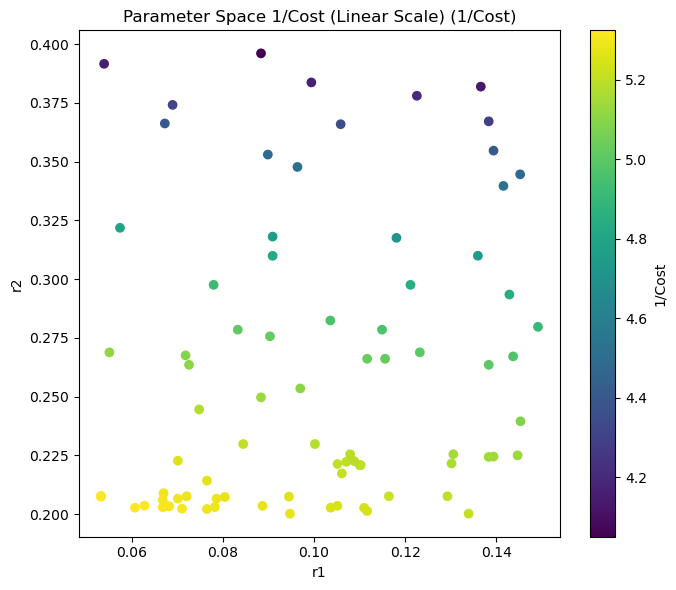

In [11]:
data_file = optimizer.data_file

from src.optimization_data_analyzer import OptimizationDataAnalyzer
analyzer = OptimizationDataAnalyzer(data_file)

analyzer.plot_raw_data(points_only=True, plot_inverse_cost=True)